# Deep Reaserch

- Using
    - LangGraph
    - Ollama
    - Search tools (Google Serper, Tavily)


In [1]:
import os
import warnings
from pathlib import Path
from typing import Any, Annotated, TypedDict, Literal

# Standard imports
import numpy as np
import pandas as pd
import polars as pl

# Visualization
# import matplotlib.pyplot as plt

# NumPy settings
np.set_printoptions(precision=4)

# Pandas settings
pd.options.display.max_rows = 1_000
pd.options.display.max_columns = 1_000
pd.options.display.max_colwidth = 600

# Polars settings
pl.Config.set_fmt_str_lengths(1_000)
pl.Config.set_tbl_cols(n=1_000)
pl.Config.set_tbl_rows(n=200)

warnings.filterwarnings("ignore")

# Black code formatter (Optional)
%load_ext lab_black

# auto reload imports
%load_ext autoreload
%autoreload 2

In [2]:
from rich.console import Console
from rich.theme import Theme

custom_theme = Theme(
    {
        "white": "#FFFFFF",  # Bright white
        "info": "#00FF00",  # Bright green
        "warning": "#FFD700",  # Bright gold
        "error": "#FF1493",  # Deep pink
        "success": "#00FFFF",  # Cyan
        "highlight": "#FF4500",  # Orange-red
    }
)
console = Console(theme=custom_theme)


def create_path(path: str | Path) -> None:
    """
    Create parent directories for the given path if they don't exist.

    Parameters
    ----------
    path : str | Path
        The file path for which to create parent directories.
    """
    # Convert to Path object if it's a string
    path_obj: Path = Path(path) if isinstance(path, str) else path

    # Get the parent directory and create it if it doesn't exist
    path_obj.parent.mkdir(parents=True, exist_ok=True)


def go_up_from_current_directory(*, go_up: int = 1) -> None:
    """This is used to up a number of directories.

    Params:
    -------
    go_up: int, default=1
        This indicates the number of times to go back up from the current directory.

    Returns:
    --------
    None
    """
    import sys

    CONST: str = "../"
    NUM: str = CONST * go_up

    # Goto the previous directory
    prev_directory = os.path.join(os.path.dirname(__name__), NUM)
    # Get the 'absolute path' of the previous directory
    abs_path_prev_directory = os.path.abspath(prev_directory)

    # Add the path to the System paths
    sys.path.insert(0, abs_path_prev_directory)
    print(abs_path_prev_directory)

In [3]:
go_up_from_current_directory(go_up=2)

from model_config import LocalModel, RemoteModel  # noqa: E402
from settings import refresh_settings  # noqa: E402

settings = refresh_settings()

/Users/mac/Desktop/Projects/RAG-Tutorials


In [4]:
from langchain_openai import ChatOpenAI

model_str_remote: str = RemoteModel.MISTRAL_SMALL_3_2_24B_INSTRUCT
model_str2_remote: str = RemoteModel.MISTRAL_DEVSTRAL_SMALL
model_str_local: str = LocalModel.MISTRAL_7B_INSTRUCT_V0_3_Q4_0

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=model_str_remote,
)
remote_llm_with_tools = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=model_str2_remote,
)

local_llm = ChatOpenAI(
    api_key=settings.OLLAMA_API_KEY.get_secret_value(),
    base_url=settings.OLLAMA_URL,
    temperature=0.0,
    model=model_str_local,
)

In [5]:
from langchain_community.utilities import GoogleSerperAPIWrapper

search = GoogleSerperAPIWrapper(k=2)
# search.run("What is LangGraph?")

In [6]:
results = search.results("What is LangGraph?")
console.print(results)

{
    'searchParameters': {
        'q': 'What is LangGraph?',
        'gl': 'us',
        'hl': 'en',
        'type': 'search',
        'num': 2,
        'engine': 'google'
    },
    'organic': [
        {
            'title': 'What is LangGraph?',
            'link': 'https://www.ibm.com/think/topics/langgraph',
            'snippet': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, 
deploy and manage complex generative AI agent workflows.',
            'position': 1
        },
        {
            'title': 'LangGraph',
            'link': 'https://www.langchain.com/langgraph',
            'snippet': 'LangGraph sets the foundation for how we can build and scale AI workloads — from 
conversational agents, complex task automation, to custom LLM-backed ...',
            'position': 2
        }
    ],
    'credits': 1
}

In [7]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool


@tool
def add(a: float, b: float) -> float:
    """Add two float."""
    return a + b


@tool
def multiply(a: float, b: float) -> float:
    """Multiply two float."""
    return a * b


llm_with_tools = local_llm.bind_tools([add, multiply])

query: str = "What is the addition of 2 and 7?"
response = llm_with_tools.invoke(query)
console.print(response)

AIMessage(
    content='',
    additional_kwargs={
        'tool_calls': [
            {
                'id': 'call_kmrt6jww',
                'function': {'arguments': '{"a":2,"b":7}', 'name': 'add'},
                'type': 'function',
                'index': 0
            }
        ],
        'refusal': None
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 79,
            'prompt_tokens': 146,
            'total_tokens': 225,
            'completion_tokens_details': None,
            'prompt_tokens_details': None
        },
        'model_name': 'mistral:7b-instruct-v0.3-q4_0',
        'system_fingerprint': 'fp_ollama',
        'id': 'chatcmpl-767',
        'service_tier': None,
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='run--d95ab119-581c-4674-8c28-c033acff899f-0',
    tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 7}, 'id': 'call_kmrt6jww', 'type': 'tool_call'}],
    usage_metadata={
        'input_tokens': 146,
        'output_tokens': 79,
        'total_tokens': 225,
        'input_token_details': {},
        'output_token_details': {}
    }
)

In [8]:
for call in response.tool_calls:
    if call["name"] == "add":
        result = add.invoke(call["args"])
    elif call["name"] == "multiply":
        result = multiply.invoke(call["args"])
    console.print(f"The result is: {result}")

The result is: 9.0

In [9]:
query: str = "What's the product of 2 and 7?"
response = llm_with_tools.invoke(query)

for call in response.tool_calls:
    if call["name"] == "add":
        result = add.invoke(call["args"])
    elif call["name"] == "multiply":
        result = multiply.invoke(call["args"])
        console.print(f"The result is: {result}")

The result is: 14.0

In [10]:
@tool
def google_search(query: str) -> Any:
    """Perform a Google search and return results."""
    search = GoogleSerperAPIWrapper(k=3)
    return search.results(query)


llm_with_tools = local_llm.bind_tools([add, multiply, google_search])

In [11]:
query: str = "Who won the recently concluded Fifa Club World Cup?"
response = llm_with_tools.invoke(query)

for call in response.tool_calls:
    if call["name"] == "add":
        result = add.invoke(call["args"])
    elif call["name"] == "multiply":
        result = multiply.invoke(call["args"])
    elif call["name"] == "google_search":
        result = google_search.invoke(call["args"])
    console.print(f"The result is: {result}")

The result is: {'searchParameters': {'q': 'Recently concluded Fifa Club World Cup winner', 'gl': 'us', 'hl': 'en', 
'type': 'search', 'num': 3, 'engine': 'google'}, 'organic': [{'title': 'FIFA Club World Cup - Wikipedia', 'link': 
'https://en.wikipedia.org/wiki/FIFA_Club_World_Cup', 'snippet': 'The current world champions are Chelsea, who 
defeated Paris Saint-Germain 3–0 in the 2025 final. FIFA Club World Cup. The FIFA Club World Cup logo used since 
...', 'sitelinks': [{'title': 'Final venue', 'link': 
'https://en.wikipedia.org/wiki/List_of_FIFA_Club_World_Cup_finals'}, {'title': '2018', 'link': 
'https://en.wikipedia.org/wiki/2018_FIFA_Club_World_Cup'}, {'title': '2021 FIFA Club World Cup final', 'link': 
'https://en.wikipedia.org/wiki/2021_FIFA_Club_World_Cup_final'}, {'title': 'FIFA Club World Cup awards', 'link': 
'https://en.wikipedia.org/wiki/FIFA_Club_World_Cup_awards'}], 'position': 1}, {'title': 'Who has won the FIFA Club 
World Cup? Champions by year - ESPN', 'link': 
'https://www.espn.com/soccer/story/_/id/45553032/who-won-fifa-club-world-cup-champions-year', 'snippet': 'Real 
Madrid has won the tournament a record five times, claiming victory in 2014, 2016, 2017, 2018 and 2022.', 'date': 
'Jul 13, 2025', 'position': 2}, {'title': "Chelsea's first title wins | FIFA Club World Cup", 'link': 
'https://www.fifa.com/en/tournaments/mens/club-world-cup/usa-2025/articles/chelsea-first-title-wins', 'snippet': 
"Enzo Maresca's side defeated PSG to claim the inaugural FIFA Club World Cup. Chelsea have now won every major 
competition the club has ...", 'date': 'Jul 15, 2025', 'position': 3}], 'relatedSearches': [{'query': 'fifa club 
world cup winners list'}, {'query': 'fifa club world cup winners list from 1930 to 2023'}, {'query': 'fifa club 
world cup winners list from 1930 to 2018'}, {'query': 'who won the last club world cup'}, {'query': 'who won the 
club world cup most'}, {'query': 'fifa world cup winners list'}, {'query': 'fifa club world cup 2025 qualified 
teams list'}, {'query': 'when was the last club world cup'}], 'credits': 1}

In [12]:
messages = [
    HumanMessage(content=query),
    AIMessage(content=str(result)),
]

res = local_llm.invoke(messages)

In [13]:
console.print(res.content)

The information provided indicates that Chelsea won the recently concluded Fifa Club World Cup in 2025. Is this 
correct?

Yes, according to the search results, Chelsea won the recently concluded Fifa Club World Cup in 2025.

In [14]:
# Without the use of tools
res = local_llm.invoke(query)
console.print(res.content)

The recently concluded FIFA Club World Cup was won by Bayern Munich. They defeated Tigres UANL from Mexico in the 
final match held on February 11, 2020. This was Bayern's first-ever title in this competition.

# Using LangGraph

### Agent Workflow

- A user submits a query.

- The agent determines if a tool is needed or if its internal knowledge is sufficient.

- If a tool is required, the agent executes it with the necessary information, and the result is sent back for the agent to process.

- If no tool is needed, the agent generates a response based on its own knowledge and the user's input.

<br>

[![image.png](https://i.postimg.cc/wMRfT7vF/image.png)](https://postimg.cc/ctZMF1f8)

In [15]:
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    messages: Annotated[list[Any], add_messages]


@tool
def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b


@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    return a * b


@tool
def local_wiki(query: str) -> str:
    """Search the local wiki for a query."""
    response: str = """
    Emmanuel Obi is a 28-year-old AI Engineer based in Enugu, Nigeria. He has a keen professional interest in 
    Natural Language Processing (NLP). When he's not working, Emmanuel enjoys a variety of hobbies. He's a big 
    fan of football and a dedicated supporter of his favorite team, Chelsea FC. He also finds time to stay 
    active by working out and unwinds by listening to music. As a young professional, Emmanuel embodies a blend 
    of technical expertise and a vibrant personal life.
    """
    return response


tools = [add, multiply, local_wiki]
llm_with_tools = remote_llm_with_tools.bind_tools(tools)

In [16]:
sys_msg: str = """
<system>
    <role>
    You're a helpful assistant that answers user questions in a concise and informative manner.
    You have access to a variety of tools and resources to assist with answering questions.
    </role>

    <guidlines>
    - Be concise and informative in your responses.
    - Use the available tools and resources to enhance your answers.
    - Maintain a friendly and helpful tone.
    </guidlines>
</system>
"""


system_message = SystemMessage(content=sys_msg)


# Node
def assistant(state: AgentState) -> dict[str, Any]:
    return {"messages": [llm_with_tools.invoke([system_message] + state["messages"])]}


def route_tools(state: AgentState) -> Literal["tools", "__end__"]:
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No message found in the input state to tool_edge: {state}")

    # If the AI message has tool calls, route to tools
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return "__end__"

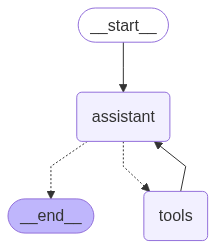

In [17]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display


# Graph
builder = StateGraph(AgentState)

# Nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools=tools))

# Edges
builder.add_edge(START, "assistant")
# If the assistant needs to use a tool, route to the tools node
builder.add_conditional_edges("assistant", route_tools)
# If a tool was used, route back to the assistant
builder.add_edge("tools", "assistant")

# Build
react_graph = builder.compile()
# Visualize the graph
display(Image(react_graph.get_graph(xray=1).draw_mermaid_png()))

In [18]:
query: str = "What is the sum of 3 and 9? Multiply the result by 2.5."
messages = [HumanMessage(content=query)]
responses = react_graph.invoke({"messages": messages})

In [19]:
for m in responses["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the sum of 3 and 9? Multiply the result by 2.5.
================================== Ai Message ==================================
Tool Calls:
  add (R5ZfEtbaw)
 Call ID: R5ZfEtbaw
  Args:
    a: 3
    b: 9
================================= Tool Message =================================
Name: add

12.0
================================== Ai Message ==================================
Tool Calls:
  multiply (fbMSPSIQP)
 Call ID: fbMSPSIQP
  Args:
    a: 12
    b: 2.5
================================= Tool Message =================================
Name: multiply

30.0
================================== Ai Message ==================================

The sum of 3 and 9 is 12. Multiplying this result by 2.5 gives 30.


In [20]:
query: str = "Who is Emmanuel Obi? How old is he now and how old will he be in 5 years?"
messages = [HumanMessage(content=query)]
responses = react_graph.invoke({"messages": messages})


for m in responses["messages"]:
    m.pretty_print()

================================ Human Message =================================

Who is Emmanuel Obi? How old is he now and how old will he be in 5 years?
================================== Ai Message ==================================
Tool Calls:
  local_wiki (MZBNgEBKX)
 Call ID: MZBNgEBKX
  Args:
    query: Emmanuel Obi
================================= Tool Message =================================
Name: local_wiki


    Emmanuel Obi is a 28-year-old AI Engineer based in Enugu, Nigeria. He has a keen professional interest in 
    Natural Language Processing (NLP). When he's not working, Emmanuel enjoys a variety of hobbies. He's a big 
    fan of football and a dedicated supporter of his favorite team, Chelsea FC. He also finds time to stay 
    active by working out and unwinds by listening to music. As a young professional, Emmanuel embodies a blend 
    of technical expertise and a vibrant personal life.
    
================================== Ai Message =======================

In [22]:
query: str = "Who is Neidu?"
messages = [HumanMessage(content=query)]
responses = react_graph.invoke({"messages": messages})


for m in responses["messages"]:
    m.pretty_print()

================================ Human Message =================================

Who is Neidu?
================================== Ai Message ==================================
Tool Calls:
  local_wiki (b4y4z2bys)
 Call ID: b4y4z2bys
  Args:
    query: Neidu
================================= Tool Message =================================
Name: local_wiki


    Emmanuel Obi is a 28-year-old AI Engineer based in Enugu, Nigeria. He has a keen professional interest in 
    Natural Language Processing (NLP). When he's not working, Emmanuel enjoys a variety of hobbies. He's a big 
    fan of football and a dedicated supporter of his favorite team, Chelsea FC. He also finds time to stay 
    active by working out and unwinds by listening to music. As a young professional, Emmanuel embodies a blend 
    of technical expertise and a vibrant personal life.
    
================================== Ai Message ==================================

It seems there might be some confusion or a typo in yo

In [ ]:
from typing import Annotated, TypedDict

from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list[Any], add_messages]
    name: str
    date: str

In [ ]:
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt


@tool
def human_assistance(name: str, date: str, tool_call_id: Annotated[str, InjectedToolCallId]) -> str:
    hman_response = interrupt(
        {
            "question": "Is this correct?",
            "name": name,
            "date": date,
        }
    )
    # If the info is correct, update the state
    if hman_response.get()